Correlation coefficient: 0.003


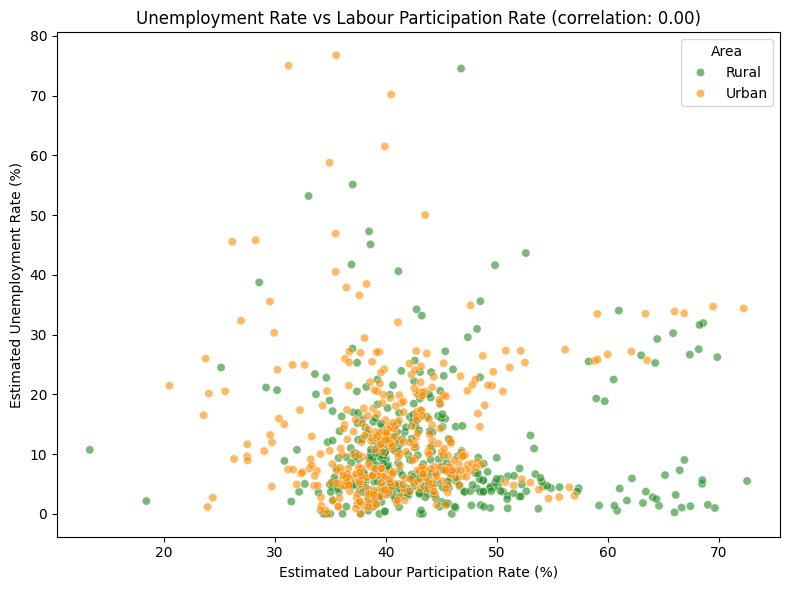

In [9]:
correlation = df['Estimated Unemployment Rate (%)'].corr(df['Estimated Labour Participation Rate (%)'])
print(f"Correlation coefficient: {correlation:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Estimated Labour Participation Rate (%)', y='Estimated Unemployment Rate (%)', 
                 hue='Area', palette={'Rural': 'forestgreen', 'Urban': 'darkorange'}, alpha=0.6)
plt.title(f'Unemployment Rate vs Labour Participation Rate (correlation: {correlation:.2f})')
plt.tight_layout()
plt.savefig('../visualizations/06_correlation_scatter.png', dpi=150)
plt.show()

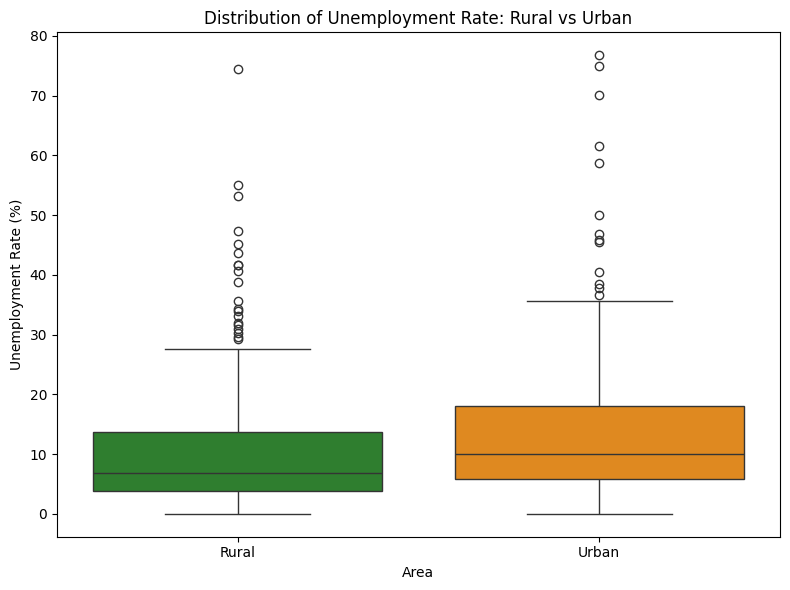

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', hue='Area', palette={'Rural': 'forestgreen', 'Urban': 'darkorange'}, legend=False)
plt.title('Distribution of Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../visualizations/05_boxplot_rural_urban.png', dpi=150)
plt.show()

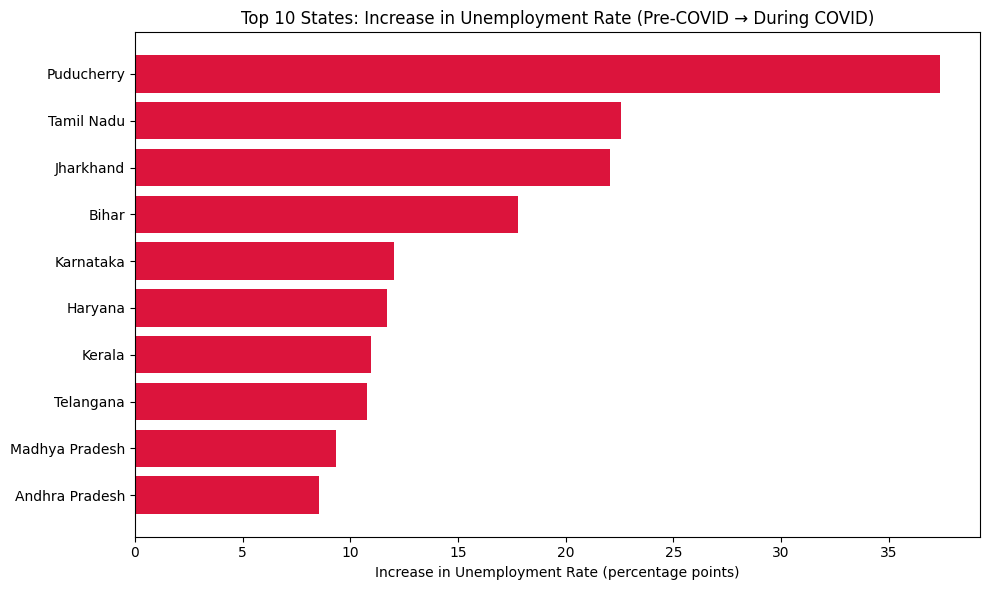

In [7]:
top10 = state_comparison.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index[::-1], top10['Increase (pp)'][::-1], color='crimson')
plt.title('Top 10 States: Increase in Unemployment Rate (Pre-COVID → During COVID)')
plt.xlabel('Increase in Unemployment Rate (percentage points)')
plt.tight_layout()
plt.savefig('../visualizations/04_top10_states_increase.png', dpi=150)
plt.show()

In [6]:
# Calculate average unemployment per state, for pre-COVID and during-COVID periods separately
state_pre = pre_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
state_covid = covid_period.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

state_comparison = pd.DataFrame({
    'Pre-COVID': state_pre,
    'During COVID': state_covid
})
state_comparison['Increase (pp)'] = state_comparison['During COVID'] - state_comparison['Pre-COVID']
state_comparison = state_comparison.sort_values('Increase (pp)', ascending=False)

print(state_comparison.head(10))

                Pre-COVID  During COVID  Increase (pp)
Region                                                
Puducherry         1.5930      38.95500       37.36200
Tamil Nadu         2.8365      25.40375       22.56725
Jharkhand         14.2795      36.34875       22.06925
Bihar             13.8330      31.63125       17.79825
Karnataka          3.2345      15.28000       12.04550
Haryana           22.9355      34.65250       11.71700
Kerala             6.9925      17.95250       10.96000
Telangana          4.6560      15.44250       10.78650
Madhya Pradesh     4.7410      14.07000        9.32900
Andhra Pradesh     5.0375      13.57625        8.53875


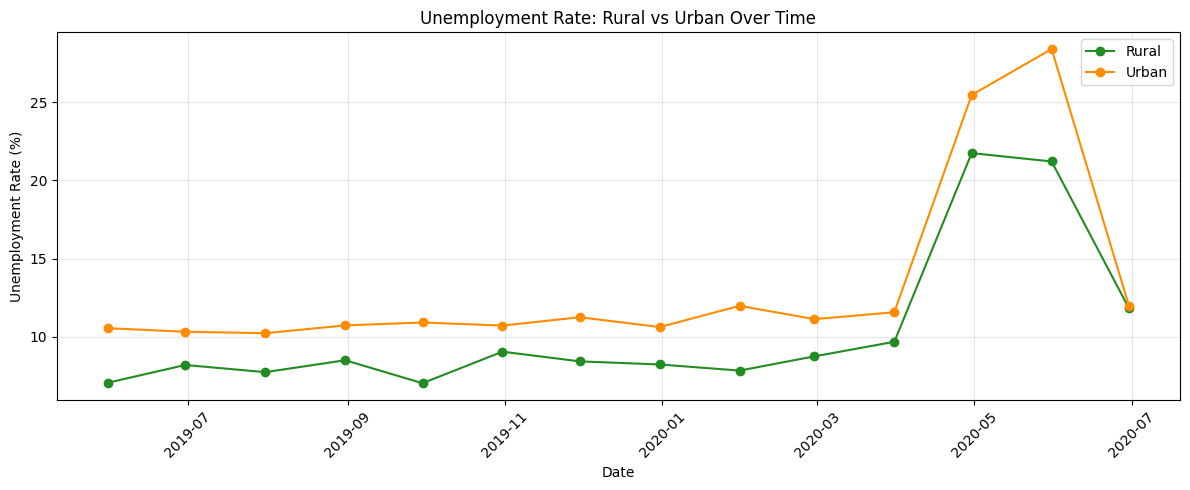

In [5]:
# Aggregate by Date AND Area, then average
area_trend = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().unstack()

plt.figure(figsize=(12, 5))
plt.plot(area_trend.index, area_trend['Rural'], marker='o', label='Rural', color='forestgreen')
plt.plot(area_trend.index, area_trend['Urban'], marker='o', label='Urban', color='darkorange')
plt.title('Unemployment Rate: Rural vs Urban Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/03_rural_vs_urban.png', dpi=150)
plt.show()

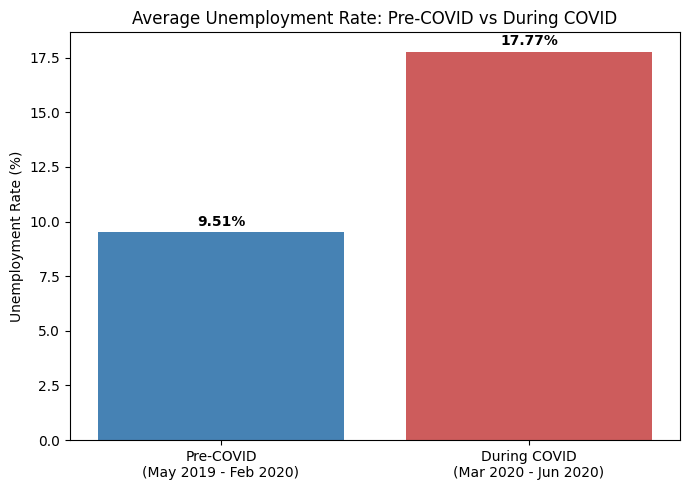

In [4]:
periods = ['Pre-COVID\n(May 2019 - Feb 2020)', 'During COVID\n(Mar 2020 - Jun 2020)']
values = [pre_covid_avg, covid_avg]

plt.figure(figsize=(7, 5))
bars = plt.bar(periods, values, color=['steelblue', 'indianred'])
plt.title('Average Unemployment Rate: Pre-COVID vs During COVID')
plt.ylabel('Unemployment Rate (%)')

# Add value labels on top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.2f}%', 
              ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/02_pre_vs_during_covid.png', dpi=150)
plt.show()

In [3]:
# Define periods: Pre-COVID (before March 2020) vs COVID period (March 2020 onwards)
pre_covid = df[df['Date'] < '2020-03-01']
covid_period = df[df['Date'] >= '2020-03-01']

pre_covid_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
covid_avg = covid_period['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-COVID average unemployment rate (May 2019 - Feb 2020): {pre_covid_avg:.2f}%")
print(f"During COVID average unemployment rate (Mar 2020 - Jun 2020): {covid_avg:.2f}%")
print(f"Increase: {covid_avg - pre_covid_avg:.2f} percentage points")
print(f"Relative increase: {((covid_avg - pre_covid_avg) / pre_covid_avg) * 100:.1f}%")

Pre-COVID average unemployment rate (May 2019 - Feb 2020): 9.51%
During COVID average unemployment rate (Mar 2020 - Jun 2020): 17.77%
Increase: 8.26 percentage points
Relative increase: 86.9%


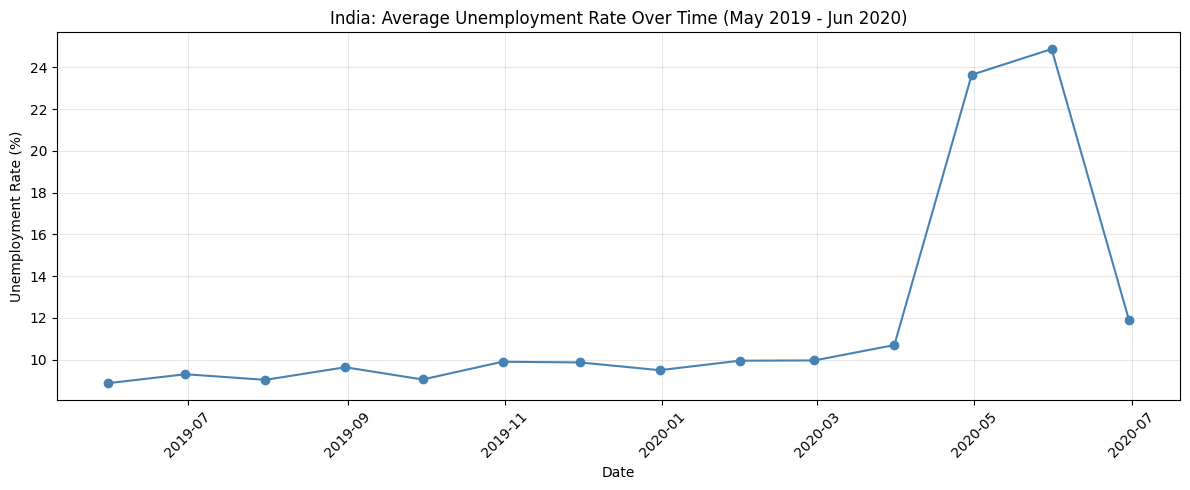

In [2]:
# Aggregate: average unemployment rate across all regions, per date
national_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 5))
plt.plot(national_trend.index, national_trend.values, marker='o', color='steelblue')
plt.title('India: Average Unemployment Rate Over Time (May 2019 - Jun 2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/01_national_trend.png', dpi=150)
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/unemployment_cleaned.csv", parse_dates=['Date'])

print(df.shape)
df.head()

(740, 6)


,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural
